In [2]:
import os
from pathlib import Path
import numpy as np
import SimpleITK as sitk
import scipy.ndimage as ndi


def normalize_volume(volume, method="z-score"):
    """
    Normalize a 3D volume.
    method:
        - 'z-score': (x - mean) / std
        - 'min-max': scaled to [0, 1]
    """
    volume = volume.astype(np.float32)

    if method == "z-score":
        mu = float(volume.mean())
        sigma = float(volume.std())
        if sigma < 1e-8:
            return volume - mu
        return (volume - mu) / sigma

    elif method == "min-max":
        v_min = float(volume.min())
        v_max = float(volume.max())
        if (v_max - v_min) < 1e-8:
            return volume - v_min
        return (volume - v_min) / (v_max - v_min)

    else:
        raise ValueError("method must be 'z-score' or 'min-max'")


def get_bounding_box_from_ct(ct_array, threshold=-500, pad=3):
    """
    Find a tight 3D bounding box from CT using the largest connected body component.
    Input ct_array is expected in z, y, x order.
    """
    body_mask = ct_array > threshold
    labels, num_features = ndi.label(body_mask)

    if num_features == 0:
        return None

    counts = np.bincount(labels.ravel())
    counts[0] = 0
    largest_component_label = counts.argmax()

    clean_body_mask = labels == largest_component_label
    z_idx, y_idx, x_idx = np.where(clean_body_mask)

    if len(z_idx) == 0:
        return None

    z_min, z_max = z_idx.min(), z_idx.max()
    y_min, y_max = y_idx.min(), y_idx.max()
    x_min, x_max = x_idx.min(), x_idx.max()

    z_min = max(0, z_min - pad)
    z_max = min(ct_array.shape[0], z_max + pad + 1)
    y_min = max(0, y_min - pad)
    y_max = min(ct_array.shape[1], y_max + pad + 1)
    x_min = max(0, x_min - pad)
    x_max = min(ct_array.shape[2], x_max + pad + 1)

    return slice(z_min, z_max), slice(y_min, y_max), slice(x_min, x_max)


def make_pet_reference_image(pet_img, target_spacing_xyz=(2.0, 2.0, 3.0)):
    """
    Build a PET reference image at target spacing.
    Directly use original PET spacing metadata without rounding.
    """
    orig_size = np.array(list(pet_img.GetSize()), dtype=np.int32)         # x, y, z
    orig_spacing = np.array(list(pet_img.GetSpacing()), dtype=np.float32) # x, y, z

    used_spacing = orig_spacing.copy()
    target_spacing = np.array(target_spacing_xyz, dtype=np.float32)

    new_size = np.round(orig_size * used_spacing / target_spacing).astype(np.int32)
    new_size = np.maximum(new_size, 1)

    ref = sitk.Image([int(x) for x in new_size], pet_img.GetPixelID())
    ref.SetSpacing(tuple(float(x) for x in target_spacing))
    ref.SetOrigin(pet_img.GetOrigin())
    ref.SetDirection(pet_img.GetDirection())

    return ref, used_spacing, target_spacing, new_size


def resample_to_reference(img, ref_img, interpolator, default_value=0.0):
    """
    Resample an image onto ref_img grid.
    """
    return sitk.Resample(
        img,
        ref_img,
        sitk.Transform(),
        interpolator,
        default_value,
        img.GetPixelID()
    )


def process_deeppsma_dataset(
    source_base="/data24/xl693/DeepPSMA",
    target_base="/gluon4/xl693/PETCTfoundation/DeepPSMA",
    target_spacing_xyz=(2.0, 2.0, 3.0),
    pet_norm="z-score",
    ct_norm="z-score"
):
    """
    Process DeepPSMA dataset only.

    Input structure example:
      /data24/xl693/DeepPSMA/0001-0020/train_0001/FDG/PET.nii.gz
      /data24/xl693/DeepPSMA/0001-0020/train_0001/FDG/CT.nii.gz

    Output:
      /gluon4/xl693/PETCTfoundation/DeepPSMA/0001-0020/train_0001/FDG/PET.npy

    Saved array shape:
      (2, Z, Y, X)
      channel 0 = PET
      channel 1 = CT
    """
    source_base = Path(source_base)
    target_base = Path(target_base)

    if not source_base.exists():
        raise FileNotFoundError(f"Source directory not found: {source_base}")

    pet_paths = sorted(source_base.rglob("FDG/PET.nii.gz"))
    print(f"Found {len(pet_paths)} PET files under {source_base}")

    num_ok = 0
    num_fail = 0

    for pet_path in pet_paths:
        ct_path = pet_path.parent / "CT.nii.gz"

        if not ct_path.exists():
            print(f"[Skip] Missing CT: {ct_path}")
            num_fail += 1
            continue

        try:
            rel_pet_path = pet_path.relative_to(source_base)
            save_path = target_base / rel_pet_path
            save_path = save_path.with_suffix("").with_suffix(".npy")

            print(f"\nProcessing: {rel_pet_path}")

            # ---------------- Load ----------------
            pet_img = sitk.ReadImage(str(pet_path))
            ct_img = sitk.ReadImage(str(ct_path))

            # ---------------- Build PET target reference ----------------
            pet_ref, used_pet_spacing, target_spacing, new_pet_size = make_pet_reference_image(
                pet_img,
                target_spacing_xyz=target_spacing_xyz
            )

            # ---------------- Resample ----------------
            pet_resampled_img = resample_to_reference(
                pet_img, pet_ref, sitk.sitkLinear, default_value=0.0
            )

            ct_resampled_img = resample_to_reference(
                ct_img, pet_ref, sitk.sitkLinear, default_value=-1024.0
            )

            pet_resampled = sitk.GetArrayFromImage(pet_resampled_img).astype(np.float32)  # z,y,x
            ct_resampled = sitk.GetArrayFromImage(ct_resampled_img).astype(np.float32)    # z,y,x

            # ---------------- Crop empty area ----------------
            bbox = get_bounding_box_from_ct(ct_resampled, threshold=-500, pad=3)
            if bbox is not None:
                pet_crop = pet_resampled[bbox]
                ct_crop = ct_resampled[bbox]
            else:
                pet_crop = pet_resampled
                ct_crop = ct_resampled

            # ---------------- Normalize separately ----------------
            pet_norm_arr = normalize_volume(pet_crop, method=pet_norm)
            ct_norm_arr = normalize_volume(ct_crop, method=ct_norm)

            # ---------------- Stack ----------------
            stacked = np.stack([pet_norm_arr, ct_norm_arr], axis=0).astype(np.float32)

            # ---------------- Save ----------------
            save_path.parent.mkdir(parents=True, exist_ok=True)
            np.save(save_path, stacked)

            print(f"  PET original spacing xyz: {pet_img.GetSpacing()}")
            print(f"  PET used spacing xyz:     {tuple(used_pet_spacing.tolist())}")
            print(f"  Target spacing xyz:       {tuple(target_spacing.tolist())}")
            print(f"  Target PET size xyz:      {tuple(new_pet_size.tolist())}")
            print(f"  Final saved shape:        {stacked.shape}")
            print(f"  Saved to:                 {save_path}")

            num_ok += 1

        except Exception as e:
            print(f"[Error] Failed on {pet_path}: {e}")
            num_fail += 1

    print("\nDone.")
    print(f"Successful: {num_ok}")
    print(f"Failed:     {num_fail}")


if __name__ == "__main__":
    process_deeppsma_dataset(
        source_base="/data24/xl693/DeepPSMA",
        target_base="/gluon4/xl693/PETCTfoundation/DeepPSMA",
        target_spacing_xyz=(2.0, 2.0, 3.0),
        pet_norm="z-score",   # or "min-max"
        ct_norm="z-score"     # or "min-max"
    )

Found 100 PET files under /data24/xl693/DeepPSMA

Processing: 0001-0020/train_0001/FDG/PET.nii.gz
  PET original spacing xyz: (2.8645832538604736, 2.8645832538604736, 3.2700002193450928)
  PET used spacing xyz:     (2.8645832538604736, 2.8645832538604736, 3.2700002193450928)
  Target spacing xyz:       (2.0, 2.0, 3.0)
  Target PET size xyz:      (275, 275, 365)
  Final saved shape:        (2, 365, 202, 250)
  Saved to:                 /gluon4/xl693/PETCTfoundation/DeepPSMA/0001-0020/train_0001/FDG/PET.npy

Processing: 0001-0020/train_0002/FDG/PET.nii.gz
  PET original spacing xyz: (5.46875, 5.46875, 3.2699999809265137)
  PET used spacing xyz:     (5.46875, 5.46875, 3.2699999809265137)
  Target spacing xyz:       (2.0, 2.0, 3.0)
  Target PET size xyz:      (350, 350, 404)
  Final saved shape:        (2, 404, 267, 210)
  Saved to:                 /gluon4/xl693/PETCTfoundation/DeepPSMA/0001-0020/train_0002/FDG/PET.npy

Processing: 0001-0020/train_0003/FDG/PET.nii.gz
  PET original spacing

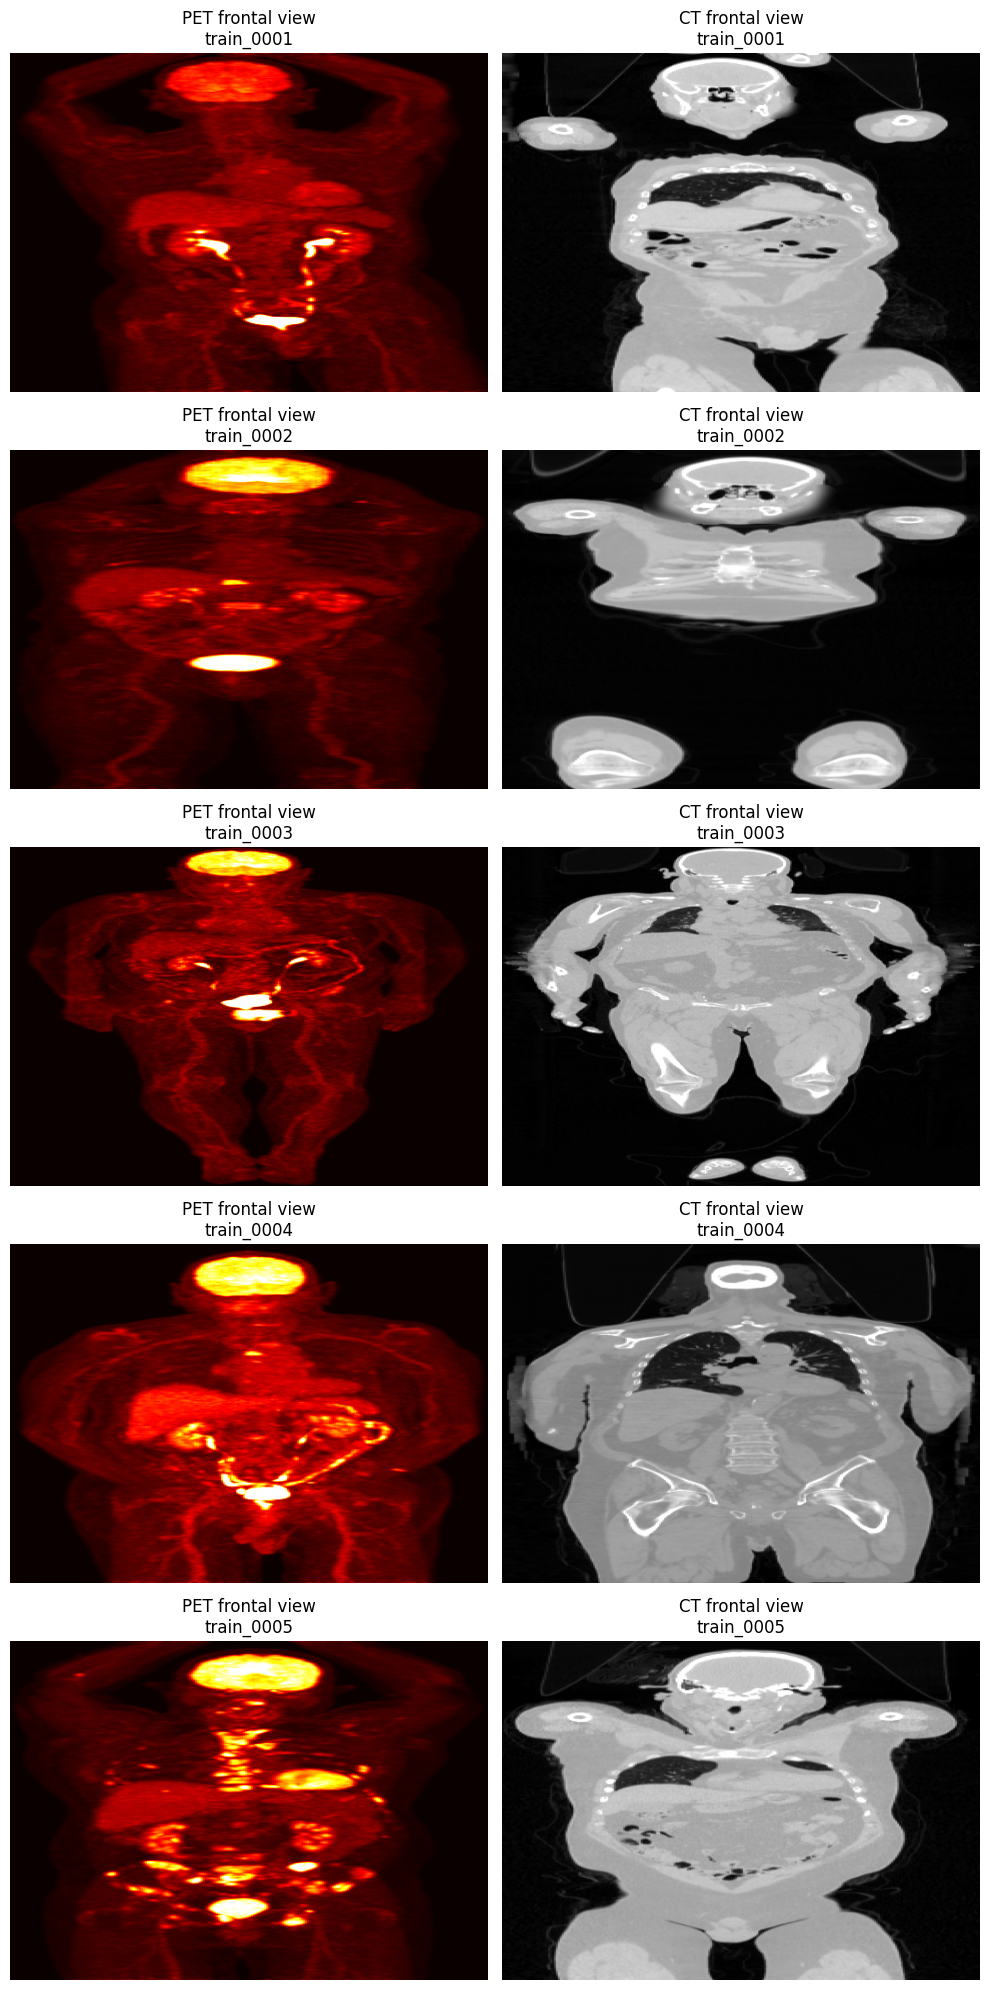

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


def find_first_n_npy(root_dir, n=5):
    root_dir = Path(root_dir)
    files = sorted(root_dir.rglob("PET.npy"))
    return files[:n]


def normalize_for_display(img, p1=1, p99=99):
    """
    Robust normalization for visualization only.
    """
    img = img.astype(np.float32)
    lo = np.percentile(img, p1)
    hi = np.percentile(img, p99)
    if hi <= lo:
        return np.zeros_like(img, dtype=np.float32)
    img = np.clip(img, lo, hi)
    img = (img - lo) / (hi - lo)
    return img


def make_coronal_pet_mip(pet_zyx):
    """
    PET shape: (Z, Y, X)
    Coronal MIP over Y -> (Z, X)
    """
    return np.max(pet_zyx, axis=1)


def make_coronal_ct_mid(ct_zyx):
    """
    CT shape: (Z, Y, X)
    Middle coronal slice over Y -> (Z, X)
    """
    y_mid = ct_zyx.shape[1] // 2
    return ct_zyx[:, y_mid, :]


def show_5_samples_frontal(root_dir="/gluon4/xl693/PETCTfoundation/DeepPSMA", n=5):
    npy_files = find_first_n_npy(root_dir, n=n)

    if len(npy_files) == 0:
        print(f"No PET.npy found under {root_dir}")
        return

    fig, axes = plt.subplots(len(npy_files), 2, figsize=(10, 4 * len(npy_files)))

    if len(npy_files) == 1:
        axes = np.array([axes])

    for i, f in enumerate(npy_files):
        arr = np.load(f)   # (2, Z, Y, X)
        pet = arr[0]
        ct = arr[1]

        pet_view = make_coronal_pet_mip(pet)   # (Z, X)
        ct_view = make_coronal_ct_mid(ct)      # (Z, X)

        pet_view = normalize_for_display(pet_view, p1=1, p99=99.5)
        ct_view = normalize_for_display(ct_view, p1=1, p99=99)

        # origin="lower" makes the body look standing upright
        axes[i, 0].imshow(pet_view, cmap="hot", origin="lower", aspect="auto")
        axes[i, 0].set_title(f"PET frontal view\n{f.parent.parent.name}")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(ct_view, cmap="gray", origin="lower", aspect="auto")
        axes[i, 1].set_title(f"CT frontal view\n{f.parent.parent.name}")
        axes[i, 1].axis("off")

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    show_5_samples_frontal("/gluon4/xl693/PETCTfoundation/DeepPSMA", n=5)